# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [25]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [26]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [27]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

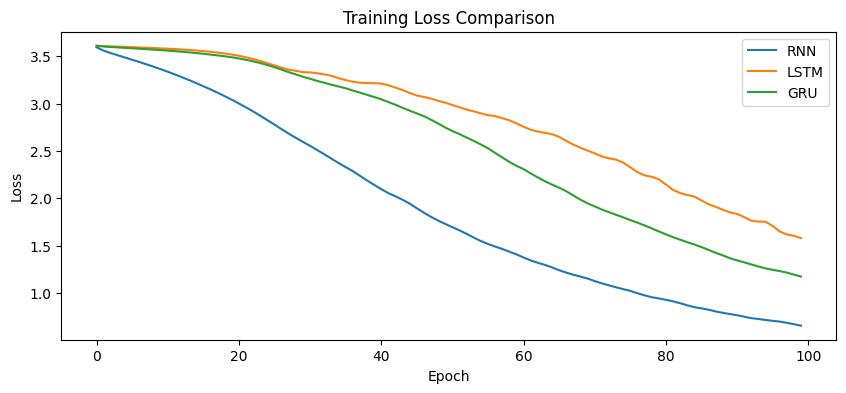

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning learning transforming transforming intelligence intelligence
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# **New Corpus**

In [28]:
corpus_v2 = '''
hello how are you
i am doing well thank you
what is your name
my name is smart assistant
nice to meet you
nice to meet you too

what can you do
i can answer questions and provide information
can you help me with my studies
yes i can help you learn new concepts
thank you for your help
you are welcome

what is artificial intelligence
artificial intelligence is the simulation of human intelligence by machines
what is machine learning
machine learning is a branch of artificial intelligence that learns from data
what is deep learning
deep learning uses neural networks with multiple layers

how does a neural network work
a neural network learns patterns from examples
why is data important
data helps models learn and make predictions
what is a dataset
a dataset is a collection of organized information

can you explain programming
programming is the process of writing instructions for computers
which programming language should i learn
python is a popular language for beginners
why is python popular
python is easy to learn and has many applications

what is data science
data science combines statistics programming and domain knowledge
what does a data scientist do
a data scientist analyzes data to extract insights
what is data analysis
data analysis is the process of examining data to discover useful information

can you help me prepare for interviews
yes i can help you practice interview questions
what are technical skills
technical skills are abilities related to specific technologies and tools
what are soft skills
soft skills include communication teamwork and problem solving

tell me about cloud computing
cloud computing provides computing resources over the internet
what is cybersecurity
cybersecurity protects systems networks and data from attacks
why is cybersecurity important
cybersecurity helps prevent unauthorized access and data breaches

what is a database
a database stores and organizes information
what is sql
sql is a language used to manage databases
what is a query
a query is a request for information from a database

how can i improve my coding skills
practice coding regularly and work on projects
how can i become a data scientist
learn statistics programming machine learning and data analysis
how can i learn artificial intelligence
study mathematics machine learning and deep learning concepts

what is teamwork
teamwork is the ability to work effectively with others
why is communication important
communication helps people share ideas clearly
how can i improve my communication skills
practice speaking listening and writing regularly

what is success
success means achieving meaningful goals
how can i stay motivated
set clear goals and track your progress
how can i manage my time
prioritize tasks and avoid distractions

what is the future of technology
technology will continue to transform industries and society
will artificial intelligence replace humans
artificial intelligence will assist humans rather than completely replace them
what skills are important for the future
adaptability creativity and continuous learning are important skills

thank you
i am happy to help
goodbye
have a great day
'''

**Tokenization**

In [29]:
tokenizer_v2 = Tokenizer()
tokenizer_v2.fit_on_texts([corpus_v2])

total_words_v2 = len(tokenizer_v2.word_index) + 1

print("Vocabulary Size:", total_words_v2)

Vocabulary Size: 200


**Create Sequences**

In [30]:
input_sequences_v2 = []

for line in corpus_v2.split('\n'):
    token_list_v2 = tokenizer_v2.texts_to_sequences([line])[0]

    for i in range(1, len(token_list_v2)):
        ngram_seq_v2 = token_list_v2[:i+1]
        input_sequences_v2.append(ngram_seq_v2)

**Padding**

In [31]:
max_len_v2 = max(len(seq) for seq in input_sequences_v2)

input_sequences_v2 = pad_sequences(
    input_sequences_v2,
    maxlen=max_len_v2,
    padding='pre'
)

X_v2 = input_sequences_v2[:, :-1]
y_v2 = input_sequences_v2[:, -1]

print("X_v2 shape:", X_v2.shape)
print("y_v2 shape:", y_v2.shape)

X_v2 shape: (416, 11)
y_v2 shape: (416,)


# **Improved RNN**

In [32]:
rnn_model_v2 = Sequential([
    Embedding(total_words_v2, 64),
    SimpleRNN(128),
    Dense(total_words_v2, activation='softmax')
])

rnn_model_v2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history_v2 = rnn_model_v2.fit(
    X_v2,
    y_v2,
    epochs=200,
    verbose=0
)

print("Improved RNN Training Completed")

Improved RNN Training Completed


# **Improved LSTM**

In [33]:
lstm_model_v2 = Sequential([
    Embedding(total_words_v2, 64),
    LSTM(128),
    Dense(total_words_v2, activation='softmax')
])

lstm_model_v2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history_v2 = lstm_model_v2.fit(
    X_v2,
    y_v2,
    epochs=200,
    verbose=0
)

print("Improved LSTM Training Completed")

Improved LSTM Training Completed


# **Improved GRU**

In [34]:
gru_model_v2 = Sequential([
    Embedding(total_words_v2, 64),
    GRU(128),
    Dense(total_words_v2, activation='softmax')
])

gru_model_v2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history_v2 = gru_model_v2.fit(
    X_v2,
    y_v2,
    epochs=200,
    verbose=0
)

print("Improved GRU Training Completed")

Improved GRU Training Completed


# **Compare Loss**

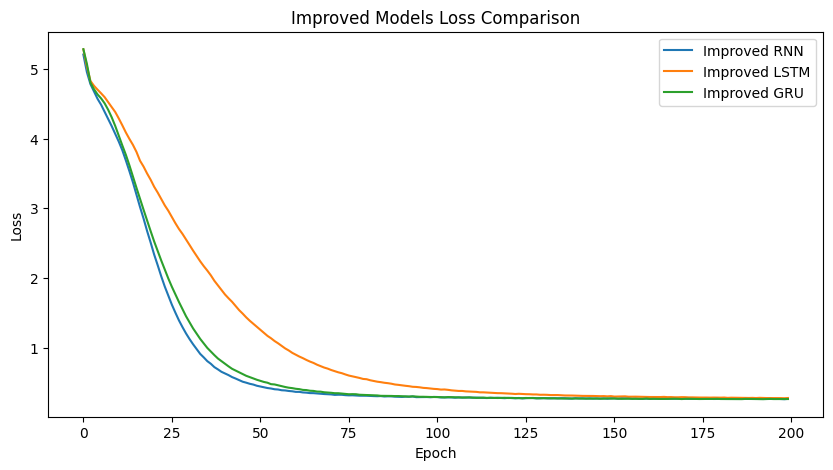

In [35]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history_v2.history['loss'], label='Improved RNN')
plt.plot(lstm_history_v2.history['loss'], label='Improved LSTM')
plt.plot(gru_history_v2.history['loss'], label='Improved GRU')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved Models Loss Comparison")

plt.legend()
plt.show()

# **Text Generation Function**

In [36]:
def generate_text_v2(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer_v2.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len_v2-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer_v2.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

# **Generate 10 Words**

In [46]:
print("Improved RNN :")
print(generate_text_v2(rnn_model_v2, "artificial", 10))

print("\nImproved LSTM :")
print(generate_text_v2(lstm_model_v2, "artificial", 10))

print("\nImproved GRU :")
print(generate_text_v2(gru_model_v2, "artificial", 10))

Improved RNN :
artificial intelligence will assist humans rather than completely replace them language

Improved LSTM :
artificial intelligence is the simulation of human intelligence by machines machines

Improved GRU :
artificial intelligence is the simulation of human intelligence by machines machines


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**